# Module 6 — The Risk Score: Building It and Deciding Whether to Trust It

## Why you're here: what the model is for
- A bank wants one number per client that says how risky the client is, which
  staff can read, explain and act on: approve, review, or decline.
- Modules 1–5 built the pieces: honest grading on rows the model didn't learn
  from (Module 1), reading a model's columns (Module 2), comparing models
  (Module 3), cut-offs and imbalanced data (Module 4), honest probabilities
  (Module 5).
- This module puts them together into a **points score** with **risk bands A–E**
  and a **cut-off**, all fixed on the training and validation rows, then grades
  it on the test rows, which Modules 1–5 never used.
- The column is still `default`: what the bank labelled default. The source data
  never defines it (Module 2), so the score predicts that label, not a
  definition we can check.

**Your endgame in this module:** build a score a bank could use, grade it once on
untouched rows, and say plainly how far it can be trusted.

## From the curriculum

> ### <u>Module 6 — The Risk Score: Building It and Deciding Whether to Trust It</u>
>
> *Checkpoint: this module builds on Modules 1–5, so it starts only after they are reviewed.*
>
> **Concepts**
> - From probability to points: a multi-factor scorecard on the log-odds scale
>   ("every 20 points doubles the odds of default"), as used in credit and
>   insurance scoring
> - Risk bands (A–E) and the checks a score must pass: default rates rise steadily
>   from band A to band E, with margins of error; the probabilities stay honest on
>   the untouched test rows; the score works equally well across groups of clients
> - Choosing a cut-off under explicit cost assumptions (cost of a missed default
>   vs. cost of a wrongly declined client)
> - Fairness: lending laws forbid scoring on sex or marital status and restrict
>   the use of age (for example the US Equal Credit Opportunity Act), so the score
>   leaves all three out, and is then checked for working equally well across
>   those groups
> - The target itself is undefined in the source data (what counts as "default" is
>   never specified, found in Module 2), so the score predicts "what the bank
>   labelled default", a limit to state alongside every result
> - Ranges for the headline grades, from re-drawn groups of test clients (the
>   bootstrap, as in Modules 1 and 3)
>
> **Why it matters**
> This is where the model becomes a decision tool. It's also the result that
> needs the most scrutiny, so the results of all three of its checks are
> independently verified (a fresh agent that sees only the claim and the data).
>
> **Worked example**
> The final points score evaluated once on the locked test rows: band table,
> honesty check, cost-based cut-off, and checks across groups of clients, each
> finding tagged.
>
> **Resources**
> - [formatpoints: format scorecard points and scaling](https://www.mathworks.com/help/finance/creditscorecard.formatpoints.html)
>   (MathWorks documentation, verified, ~10 min). How "points to double the odds"
>   scaling turns a model's log-odds into scorecard points.
> - [Equal Credit Opportunity Act](https://www.ftc.gov/legal-library/browse/statutes/equal-credit-opportunity-act)
>   (US Federal Trade Commission, verified, ~5 min). The US law behind leaving sex,
>   marital status and age out of credit decisions.
>
> **Exercise type:** a short score memo: what the score is, how well it works,
> where it shouldn't be trusted.
>
> **Interview angle:** "How would you build a risk score for X?" / "How would you
> know if the score stopped working?"

## Lesson

### What a points score is
A **points score** (in banking, a *scorecard*) gives each client a number of
points: more points = more risk. Each column adds or removes its own points, so
anyone can see where a client's total came from, for example "+29 because
September's payment was a month late" (Part 2 works out the real numbers).

### Why logistic regression, and not the forest
The forest ranked clients better (Module 3). It still can't be used here, and
the reason is how each model reaches its answer:
- **Logistic regression** (Module 2) works on the **log-odds** scale: log-odds =
  intercept + (coefficient × column 1) + (coefficient × column 2) + … , where the
  **intercept** is the log-odds of a client whose columns are all 0. Each column
  adds its **own** amount, whatever the other columns are. So each column's amount can be
  turned into points, and the points add up to the total.
- **The forest's** answer is the average of 300 trees' answers, and each tree's
  answer depends on a **combination** of columns (a chain of questions: "limit
  below 50k? then: September late? then: …"). What one column contributes changes
  with every other column, so there is no fixed amount per column to turn into
  points.
- The price of choosing logistic regression: a lower ranking grade than the
  forest (Part 1 measures it). Banks usually accept that price and choose
  logistic regression, because a forest's score can't be broken down column by
  column for a client or a regulator, and a score that can't be explained can't
  be used.

### From log-odds to points
Recall from Module 2: if p is the probability of default, the **odds** are
p ÷ (1 − p), and the log-odds are ln(odds). Points are a straight-line rescaling
of the log-odds, set by two **choices** (conventions, not facts from the data):
1. **100 points = a probability of default of 20%.** 20% is close to the share
   of defaulters in the training rows (0.221, Part 0), so a client near 100
   points is a roughly typical client.
2. **Every 20 more points doubles the odds** ("points to double the odds", a
   common way banks set the scale; 20 is a readable step). This rule works on
   odds, so first turn choice 1 into odds: 20% = odds 0.2 ÷ 0.8 = 0.25. So 100
   points = odds 0.25. Then:
   - 120 points (20 more): the odds double, 0.25 × 2 = 0.5, a probability of
     0.5 ÷ 1.5 = 33%.
   - 80 points (20 fewer): the odds halve, 0.25 ÷ 2 = 0.125, a probability of
     0.125 ÷ 1.125 = 11%.

   (To go from odds back to a probability: probability = odds ÷ (1 + odds).)

Both choices only change how the numbers look; any other pair gives the same
ranking, and therefore the same bands of clients.

**From the two choices to a formula**

1. **The 100-point client.** Choice 1: 100 points = a probability of 20%. As
   odds: 0.2 ÷ 0.8 = 0.25. As log-odds (ln of the odds): ln 0.25 = −1.386.
2. **What doubling the odds does to the log-odds.** Double the odds,
   0.25 × 2 = 0.5, and the log-odds become ln 0.5 = −0.693. The change is
   −0.693 − (−1.386) = +0.693. This is the same for every doubling; for example
   0.3 → 0.6 gives ln 0.6 − ln 0.3 = −0.511 − (−1.204) = +0.693. (0.693 is
   written ln 2.)
3. **Points per 1 of log-odds.** Choice 2: every doubling of the odds adds 20
   points. From step 2, every doubling adds 0.693 to the log-odds. So a log-odds
   difference of 0.693 is worth 20 points, and a difference of 1 is worth
   20 ÷ 0.693 = 28.85 points. (A rate per 1 is needed because clients' log-odds
   differ from −1.386 by all sorts of amounts, not only 0.693.)
4. **The formula.** Points = 100 + 28.85 × (the client's log-odds − X). To find
   X: choice 1 says a client with a 20% probability, whose log-odds = −1.386
   (step 1), must get 100 points. Put those two numbers into the formula:
   100 = 100 + 28.85 × (−1.386 − X). That holds only if −1.386 − X = 0, so
   X = −1.386. So:

   **points = 100 + 28.85 × (log-odds − (−1.386))**

Check 1: at 20%, the odds are 0.25 and the log-odds are ln 0.25 = −1.386. Put
that into the formula: points = 100 + 28.85 × (−1.386 − (−1.386)) = 100 + 28.85 × 0
= 100.

Check 2: double the odds to 0.5. The log-odds are now ln 0.5 = −0.693. Put that
into the formula: points = 100 + 28.85 × (−0.693 − (−1.386)) = 100 + 28.85 × 0.693
= 120.

### Why sex, marital status and age are left out
Lending laws limit what a bank may score clients on. In the US, the **Equal
Credit Opportunity Act** (ECOA) forbids lenders to discriminate on sex or
marital status, among other attributes, so those can't be scored on at all. Age
may be used only under strict conditions (for example, older applicants can't be
given a worse score for their age). Other countries have similar rules. The
simplest safe design is to leave all three out, and this score does.

Two consequences, both measured below:
- **What it costs:** the score may rank a little worse without them (Part 1).
- **Leaving a column out isn't enough:** other columns can carry the same
  information indirectly (for example, credit limits may differ by age). So the
  finished score is checked group by group (Part 5): does it rank equally well,
  and are its probabilities equally honest, for women and men, married and not,
  younger and older clients?

### Bands and the cut-off
- **Bands A–E** group clients by points, so staff work with five labels rather
  than a number (A = lowest risk). Five is a common choice: few enough to act on,
  enough to separate low from high risk.
- **The cut-off** is the number of points above which a client is flagged
  (here: declined). Part 3 derives it from what each kind of mistake costs.

### The checks the score must pass, on the test rows, once
In this order, since each only matters if the one before it passes:
1. **Default rates rise from band A to band E.** Pass: the bands can be used for
   decisions. Fail: the score doesn't rank risk and can't be used at all.
2. **The probabilities are honest** (Module 5's check). Pass: each client's own
   probability can be used. Fail, or pass only in part: where they aren't
   honest, use the band default rate instead.
3. **It works about equally well across groups of clients.** Pass: the score can
   be used for all groups. Fail: it needs fixing before use.

Everything (the columns, the points, the bands, the cut-off) is fixed on the
training and validation rows **before** the final grading on the test rows.

### Not a cause
The points say which clients defaulted more often in this data, not why. A client
with a lower credit limit isn't risky *because of* the limit; the bank may have
given a low limit because it already judged the client risky.

### Part 0 — Setup
Same data and same locked split as Modules 2–5: 30,000 credit-card clients of a
bank in Taiwan, April to September 2005 (Module 2). Amounts are in New Taiwan
dollars (NT$). The test rows (6,000 clients) are loaded here but not used until
Part 4.

The score itself will use only 4 columns (Part 1). They are built from Module 3's
15 prepared columns, because Module 2's 11 lack the late months April to July.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import brier_score_loss, roc_auc_score

from common import load_credit, credit_split, prepare_credit

BLUE, ORANGE, AQUA, YELLOW = "#2a78d6", "#eb6834", "#1baf7a", "#eda100"
plt.rcParams.update({"axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": True, "grid.alpha": 0.25, "figure.dpi": 110})

train, valid, test = credit_split(load_credit())
F_train, F_valid, F_test = prepare_credit(train), prepare_credit(valid), prepare_credit(test)
y_train, y_valid, y_test = train["default"].to_numpy(), valid["default"].to_numpy(), test["default"].to_numpy()
print(f"training rows: {len(y_train):,}; validation rows: {len(y_valid):,}; test rows: {len(y_test):,} (not used until Part 4)")
print(f"share of defaulters in the training rows: {y_train.mean():.3f}")
print("\nthe 15 prepared columns (Module 3):")
for c in F_train.columns:
    print(f"  {c}")

training rows: 18,000; validation rows: 6,000; test rows: 6,000 (not used until Part 4)
share of defaulters in the training rows: 0.221

the 15 prepared columns (Module 3):
  limit_k
  age
  female
  married
  edu_graduate
  edu_highschool
  edu_other
  late_sep
  late_aug
  late_jul
  late_jun
  late_may
  late_apr
  bill_sep_k
  paid_sep_k


### Part 1 — Choosing the columns (on the validation rows)
**What this part does:** decides which columns go into the score. The test comes
later (Part 4); every comparison here uses the validation rows, so the test rows
stay unused until the score is final.

**Step 1 — the proposed 4 columns.** A points score should use **few** columns,
so it stays easy to read. These 4 come from what Modules 2–3 found mattered most:
- `limit_k`: credit limit, in thousands of NT$.
- `late_sep`: months late in September, **capped at 2** (set to 2 when higher),
  because Module 2 found that the risk stops growing steadily beyond 2 months
  late, and few clients are there (printed below).
- `late_earlier`: months late added up over August to April. Module 3 found the
  sum of the late months carries almost all their information.
- `paid_sep_k`: amount paid in September, in thousands of NT$, **capped at the
  training rows' 99th percentile** (the value 99% of training clients are at or
  below), so that a handful of very large payments can't dominate a client's
  points.

**Step 2 — checking the choice.** Each alternative below is trained on the
training rows and graded (ROC-AUC) on the validation rows, then compared with the
4 columns:
- **+ September's bill** (`bill_sep_k`): does it add anything?
- **+ education**: its codes are partly undocumented (Module 2 found the
  undocumented ones produce a misleading "driver"), so it would have to add
  clearly more than chance could explain (the range below) to be worth including.
- **+ sex, marital status, age**: not allowed (Lesson); measured only to know
  what leaving them out costs.
- **all 15 prepared columns**, and **Module 3's forest** (15 columns): the best
  rankings available, for reference.
- **4 minus one column**, for each of the 4: does each one matter?

Each difference gets a **range**: the validation clients are re-drawn at random
with replacement 1,000 times (the bootstrap, as in Modules 1 and 3), the
difference is recomputed on each re-draw, and the middle 95% is the range. A range
that includes 0 means the difference could be chance.

In [2]:
PAID_CAP = F_train["paid_sep_k"].quantile(0.99)
EARLIER = ["late_aug", "late_jul", "late_jun", "late_may", "late_apr"]

def score_columns(F):
    return pd.DataFrame({"limit_k": F["limit_k"],
                         "late_sep": F["late_sep"].clip(upper=2),
                         "late_earlier": F[EARLIER].sum(axis=1),
                         "paid_sep_k": F["paid_sep_k"].clip(upper=PAID_CAP)}, index=F.index)

X_train, X_valid, X_test = score_columns(F_train), score_columns(F_valid), score_columns(F_test)
print(f"payment cap (training rows' 99th percentile): {PAID_CAP:.1f} thousand NT$")
print(f"training clients more than 2 months late in September: {(F_train['late_sep'] > 2).sum():,} of {len(F_train):,}\n")

def valid_scores(X_tr, X_va):
    m = sm.Logit(y_train, sm.add_constant(X_tr)).fit(disp=0)
    return m.predict(sm.add_constant(X_va)).to_numpy()

def plus(extra):
    return valid_scores(pd.concat([X_train, F_train[extra]], axis=1), pd.concat([X_valid, F_valid[extra]], axis=1))

forest = RandomForestClassifier(n_estimators=300, min_samples_leaf=50, n_jobs=-1, random_state=0).fit(F_train, y_train)
cands = {"the 4 columns": valid_scores(X_train, X_valid),
         "4 + September's bill": plus(["bill_sep_k"]),
         "4 + education": plus(["edu_graduate", "edu_highschool", "edu_other"]),
         "4 + sex, marital status, age": plus(["female", "married", "age"]),
         "all 15 columns (logistic)": valid_scores(F_train, F_valid),
         "Module 3's forest (15 columns)": forest.predict_proba(F_valid)[:, 1]}
for c in X_train.columns:
    cands[f"4 minus {c}"] = valid_scores(X_train.drop(columns=c), X_valid.drop(columns=c))

rng_boot = np.random.default_rng(6)
draws = [rng_boot.integers(0, len(y_valid), len(y_valid)) for _ in range(1000)]
auc = {k: roc_auc_score(y_valid, s) for k, s in cands.items()}
boot = {k: np.array([roc_auc_score(y_valid[i], s[i]) for i in draws]) for k, s in cands.items()}
base = "the 4 columns"
lo, hi = np.percentile(boot[base], [2.5, 97.5])
print(f"the 4 columns: ROC-AUC {auc[base]:.4f}, range {lo:.4f} to {hi:.4f}\n")
print(f"{'candidate':<32}{'ROC-AUC':>9}{'vs the 4 columns':>18}{'range of the difference':>26}")
for k in cands:
    if k == base: continue
    d_lo, d_hi = np.percentile(boot[k] - boot[base], [2.5, 97.5])
    print(f"{k:<32}{auc[k]:>9.4f}{auc[k] - auc[base]:>+18.4f}{d_lo:>+13.4f} to {d_hi:+.4f}")
auc_forest, auc_all15 = auc["Module 3's forest (15 columns)"], auc["all 15 columns (logistic)"]
print(f"\nforest vs logistic, same 15 columns: {auc_forest:.4f} - {auc_all15:.4f} = {auc_forest - auc_all15:.4f} (as in Module 3, Part 3)")
print(f"Brier score, validation rows: the 4 columns = {brier_score_loss(y_valid, cands[base]):.4f}; "
      f"4 columns minus limit_k = {brier_score_loss(y_valid, cands['4 minus limit_k']):.4f}")

payment cap (training rows' 99th percentile): 68.0 thousand NT$
training clients more than 2 months late in September: 264 of 18,000



the 4 columns: ROC-AUC 0.7537, range 0.7385 to 0.7680

candidate                         ROC-AUC  vs the 4 columns   range of the difference
4 + September's bill               0.7517           -0.0020      -0.0037 to -0.0003
4 + education                      0.7547           +0.0010      -0.0011 to +0.0028
4 + sex, marital status, age       0.7583           +0.0046      +0.0004 to +0.0093
all 15 columns (logistic)          0.7575           +0.0038      -0.0014 to +0.0092
Module 3's forest (15 columns)     0.7830           +0.0293      +0.0204 to +0.0382
4 minus limit_k                    0.7608           +0.0071      -0.0008 to +0.0149
4 minus late_sep                   0.7220           -0.0318      -0.0412 to -0.0225
4 minus late_earlier               0.7366           -0.0172      -0.0229 to -0.0122
4 minus paid_sep_k                 0.7493           -0.0045      -0.0079 to -0.0008

forest vs logistic, same 15 columns: 0.7830 - 0.7575 = 0.0255 (as in Module 3, Part 3)
Brier score, va

**Observation:**
- The 4 columns reach a ROC-AUC of 0.7537 on the validation rows.
- September's bill lowers it slightly (−0.0020). Education adds 0.0010, a
  difference that could be chance (its range includes 0).
- Sex, marital status and age together add 0.0046 (range +0.0004 to +0.0093):
  small, but probably real. That's what obeying the law costs here.
- The forest is ahead by 0.0293. Part of that is the forest's 11 extra columns;
  on the same 15 columns, the forest is ahead of logistic regression by 0.0255.
  That is the price of a score that can be explained column by column.
- Dropping `late_sep`, `late_earlier` or `paid_sep_k` lowers the ranking by more
  than chance could explain. Dropping `limit_k` **raises** it (+0.0071), though
  that could be chance (range −0.0008 to +0.0149).

**Hypothesis (why keep the credit limit):** logistic regression chooses its
coefficients to make the probabilities as accurate as possible, not the ranking
as good as possible, and by that yardstick the limit helps: without it, the
Brier score on the validation rows is slightly worse (printed below the table).
So the limit improves the probabilities a little and may worsen the order a
little.

**Conclusion:** the score uses the 4 columns, including the credit limit. This
choice is final from here on.

### Part 2 — From probability to points
Logistic regression is trained on the 4 columns, on the training rows only (a
choice: the validation rows stay unused by the model, so the bands, the cut-off
and the honesty check in Part 3 are set on rows it didn't learn from). It learns 5 numbers from those rows (printed below), and computes each client's
log-odds as one sum:

log-odds = −1.5896 + (−0.0013 × limit_k) + (0.9927 × late_sep) + (0.0999 × late_earlier) + (−0.0187 × paid_sep_k)

- The 4 numbers multiplied by a column are the **coefficients**.
- The 1 number not multiplied by any column (−1.5896) is the **intercept**. It's
  in every client's sum, whatever their columns are.

**Why the intercept matters here:** the points formula (Lesson) is points = 100 +
28.85 × (log-odds − (−1.386)). Put the sum above in place of "log-odds", and the
points split into parts:
- one part per column: 28.85 × coefficient × the client's value, which is that
  column's **points per unit** times the value;
- one fixed part that every client gets, from the intercept:
  100 + 28.85 × (−1.5896 − (−1.386)) = 94.13. These are the **base points**.

So every client's points = 94.13 + each column's points.

In [3]:
FACTOR = 20 / np.log(2)                      # points per 1 unit of log-odds
model = sm.Logit(y_train, sm.add_constant(X_train)).fit(disp=0)

def to_points(p):
    return 100 + FACTOR * (np.log(p / (1 - p)) - np.log(0.25))

start = 100 + FACTOR * (model.params["const"] - np.log(0.25))
per_unit = FACTOR * model.params.drop("const")
units = {"limit_k": "per 1 thousand NT$ of limit", "late_sep": "per month late (0 to 2)",
         "late_earlier": "per month late, Aug–Apr added up", "paid_sep_k": "per 1 thousand NT$ paid"}
print(f"points per unit of log-odds: 20 / ln 2 = {FACTOR:.2f}")
print(f"base points: 100 + {FACTOR:.2f} x ({model.params['const']:.4f} - ({np.log(0.25):.4f})) = {start:.2f}\n")
print(f"{'column':<14}{'coefficient':>12}{'points per unit':>17}   unit")
for c in per_unit.index:
    print(f"{c:<14}{model.params[c]:>12.4f}{per_unit[c]:>17.3f}   {units[c]}")

points per unit of log-odds: 20 / ln 2 = 28.85
base points: 100 + 28.85 x (-1.5896 - (-1.3863)) = 94.13

column         coefficient  points per unit   unit
limit_k            -0.0013           -0.037   per 1 thousand NT$ of limit
late_sep            0.9927           28.643   per month late (0 to 2)
late_earlier        0.0999            2.883   per month late, Aug–Apr added up
paid_sep_k         -0.0187           -0.539   per 1 thousand NT$ paid


Reading the table: every client gets the 94.13 base points. Each month late in
September adds 28.643 points; each month late in the earlier months adds 2.883
points; each thousand NT$ of credit limit removes 0.037 points (so a limit of 100
thousand NT$ removes 3.7 points); each thousand NT$ paid in September removes
0.539 points.

Three validation clients, worked through: the client at the 10th percentile of
points (low risk), at the 50th (middle) and at the 95th (high risk). Each line is
rounded to one decimal, so the lines can differ from the total by 0.1.

In [4]:
p_valid = model.predict(sm.add_constant(X_valid)).to_numpy()
pts_valid = to_points(p_valid)
order = np.argsort(pts_valid)
picks = {"low (10th percentile)": order[int(0.10 * len(order))],
         "middle (50th percentile)": order[int(0.50 * len(order))],
         "high (95th percentile)": order[int(0.95 * len(order))]}
for label, i in picks.items():
    x = X_valid.iloc[i]
    print(f"client {X_valid.index[i]}, {label}")
    print(f"  {'base points':<34}{start:>8.1f}")
    for c in per_unit.index:
        print(f"  {c + ' = ' + format(x[c], '.1f'):<34}{per_unit[c] * x[c]:>+8.1f}")
    total = start + (per_unit * x).sum()
    print(f"  {'total points':<34}{total:>8.1f}")
    log_odds = np.log(0.25) + (total - 100) / FACTOR
    odds = np.exp(log_odds)
    print(f"  {total:.1f} = 100 + {FACTOR:.2f} x (log-odds - ({np.log(0.25):.3f}))  ->  log-odds = {log_odds:.3f}")
    print(f"  odds = e^({log_odds:.3f}) = {odds:.3f}")
    print(f"  probability = odds / (1 + odds) = {odds:.3f} / {1 + odds:.3f} = {odds / (1 + odds):.3f}\n")

client 28087, low (10th percentile)
  base points                           94.1
  limit_k = 420.0                      -15.7
  late_sep = 0.0                        +0.0
  late_earlier = 0.0                    +0.0
  paid_sep_k = 3.6                      -2.0
  total points                          76.5
  76.5 = 100 + 28.85 x (log-odds - (-1.386))  ->  log-odds = -2.202
  odds = e^(-2.202) = 0.111
  probability = odds / (1 + odds) = 0.111 / 1.111 = 0.100

client 12107, middle (50th percentile)
  base points                           94.1
  limit_k = 100.0                       -3.7
  late_sep = 0.0                        +0.0
  late_earlier = 0.0                    +0.0
  paid_sep_k = 1.9                      -1.0
  total points                          89.4
  89.4 = 100 + 28.85 x (log-odds - (-1.386))  ->  log-odds = -1.755
  odds = e^(-1.755) = 0.173
  probability = odds / (1 + odds) = 0.173 / 1.173 = 0.147

client 2466, high (95th percentile)
  base points                          

**Observation:** each client's points turn back into a probability through the
Lesson's formula (0.100, 0.147 and 0.683). The high-risk client gets most of
their points from being late in September.

### Part 3 — Bands and the cut-off (set on the validation rows)

**Bands.** The cut points are the validation rows' 20th, 40th, 60th and 80th
percentiles of points, so each band holds a fifth of the validation clients. Equal-sized bands is a
**choice**: each band's default rate then rests on the same number of clients.

**The cut-off, calculated from what each kind of mistake costs.** Two kinds of mistake:
- a **missed default**: a client is approved and defaults (cost: the lost loan);
- a **false alarm**: a client is flagged, and so declined, but would have paid
  (cost: the lost business).

For a client with probability p, flagging costs, on average, (1 − p) × cost of a
false alarm; approving costs p × cost of a missed default. Flag when approving
costs more:

p × cost_miss > (1 − p) × cost_false_alarm  →  p > cost_false_alarm ÷ (cost_false_alarm + cost_miss)

The costs aren't in the data; a bank would supply them. Here, as an **assumption
for illustration**: a missed default costs **5 times** a false alarm. Then flag
when p > 1 ÷ (1 + 5) = 1/6. (With per-client costs, for example each client's
loan size and expected profit, the same rule gives each client their own cut-off;
this data has no profit or recovery figures, so one ratio for all clients is
used.) The table also shows two other example ratios, a
milder (2) and a harsher (10) one, to show how far the cut-off moves.

In [5]:
cuts = np.quantile(pts_valid, [0.2, 0.4, 0.6, 0.8])
BANDS = np.array(list("ABCDE"))
band_of = lambda pts: BANDS[np.digitize(pts, cuts)]
edges = [f"below {cuts[0]:.1f}"] + [f"{a:.1f} to {b:.1f}" for a, b in zip(cuts[:-1], cuts[1:])] + [f"{cuts[-1]:.1f} and above"]
band_valid = band_of(pts_valid)
valid_rate = pd.Series(y_valid).groupby(band_valid).mean()
print(f"{'band':<6}{'points':<18}{'default rate (validation)':>26}")
for b, e in zip(BANDS, edges):
    print(f"{b:<6}{e:<18}{valid_rate[b]:>26.3f}")

print("\ncut-off for different cost ratios (cost of a missed default / cost of a false alarm):")
print(f"{'ratio':>7}{'flag if p above':>17}{'= points above':>16}{'falls in band':>15}")
for ratio in [2, 5, 10]:
    p_cut = 1 / (1 + ratio)
    print(f"{ratio:>7}{p_cut:>17.3f}{to_points(p_cut):>16.1f}{band_of(to_points(p_cut)):>15}")
CUTOFF = to_points(1 / 6)
print(f"\nchosen (ratio 5): flag clients above {CUTOFF:.1f} points")

band  points             default rate (validation)
A     below 81.6                             0.093
B     81.6 to 86.9                           0.112
C     86.9 to 91.2                           0.130
D     91.2 to 114.9                          0.231
E     114.9 and above                        0.535

cut-off for different cost ratios (cost of a missed default / cost of a false alarm):
  ratio  flag if p above  = points above  falls in band
      2            0.333           120.0              E
      5            0.167            93.6              D
     10            0.091            73.6              A

chosen (ratio 5): flag clients above 93.6 points


 ratio  clients flagged   recall  precision
     1            11.8%    35.1%      65.7%
     2            17.4%    45.3%      57.6%
     3            22.7%    52.9%      51.5%
     5            29.6%    61.0%      45.6%
     7            73.3%    88.3%      26.7%
    10            93.3%    98.0%      23.2%
    15            98.2%    99.6%      22.4%
    20            98.9%    99.8%      22.3%


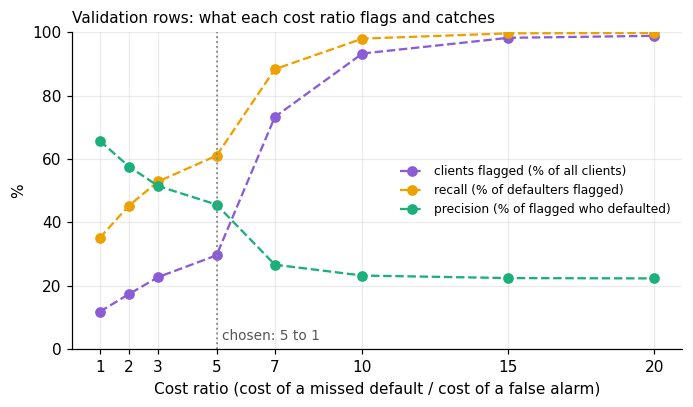

In [6]:
ratios = [1, 2, 3, 5, 7, 10, 15, 20]
flagged_share, recall_v, precision_v = [], [], []
for ratio in ratios:
    flag_v = p_valid > 1 / (1 + ratio)
    flagged_share.append(flag_v.mean())
    recall_v.append(flag_v[y_valid == 1].mean())
    precision_v.append(y_valid[flag_v].mean())
print(f"{'ratio':>6}{'clients flagged':>17}{'recall':>9}{'precision':>11}")
for r_, f_, rc_, pr_ in zip(ratios, flagged_share, recall_v, precision_v):
    print(f"{r_:>6}{f_:>17.1%}{rc_:>9.1%}{pr_:>11.1%}")

PURPLE = "#8a5cd6"
fig, ax = plt.subplots(figsize=(6.4, 3.8))
ax.plot(ratios, [v * 100 for v in flagged_share], marker="o", linestyle="--", color=PURPLE, label="clients flagged (% of all clients)")
ax.plot(ratios, [v * 100 for v in recall_v], marker="o", linestyle="--", color=YELLOW, label="recall (% of defaulters flagged)")
ax.plot(ratios, [v * 100 for v in precision_v], marker="o", linestyle="--", color=AQUA, label="precision (% of flagged who defaulted)")
ax.axvline(5, color="#888888", linestyle=":", linewidth=1.2)
ax.text(5.2, 3, "chosen: 5 to 1", fontsize=9, color="#555555")
ax.set_xticks(ratios)
ax.set_xlabel("Cost ratio (cost of a missed default / cost of a false alarm)")
ax.set_ylabel("%")
ax.set_ylim(0, 100)
ax.legend(frameon=False, loc="center right", fontsize=8)
ax.set_title("Validation rows: what each cost ratio flags and catches", fontsize=10, loc="left")
plt.tight_layout(); plt.show()

*Reading the chart: each dot is one cost ratio; the dashed lines only connect
the ratios in order.*

**Observation:** higher ratio > lower cut-off > more clients flagged and more
defaulters caught, but not smoothly:
- From 1 to 5, both rise gradually: each step flags a few more clients and
  catches a few more defaulters.
- **From 5 to 7 there's a cliff:** clients flagged jump from 29.6% to 73.3%,
  because the flag line (probability 1/8 = 0.125) falls into the range where most
  clients' probabilities sit.
- From 10 on, almost everyone is flagged (93% or more), so the score no longer
  separates anyone.

So the chosen 5 to 1 sits just before the cliff: a slightly higher ratio (for
example 7 to 1) would decline most clients.

**Observation:** each band's default rate on the validation rows is higher than
the one before it (9.3% in A up to 53.5% in E). The cut-off for a cost ratio of 5 is 93.6 points,
which falls inside band D. A bank that thinks a missed default costs 10 times a
false alarm would flag from 73.6 points (more clients flagged); at a ratio of 2,
from 120.0.

**Before the test: are the probabilities honest on the validation rows?** Module 5's
check (10 equal groups of 600, sorted by probability; each group's average
probability against its real share of defaulters, and whether the gap is within
the group's margin of error, 2 × √(real share × (1 − real share) ÷ 600)).

In [7]:
def honesty_table(p, y):
    g = pd.qcut(pd.Series(p).rank(method="first"), 10, labels=False)   # ties broken by row order, so groups stay equal-sized
    t = pd.DataFrame({"p": p, "y": y, "g": g}).groupby("g").agg(
        average_probability=("p", "mean"), real_share=("y", "mean"))
    t["gap"] = t["average_probability"] - t["real_share"]
    t["margin"] = 2 * np.sqrt(t["real_share"] * (1 - t["real_share"]) / (len(y) / 10))
    t["real_share_CI"] = [f"{r - m:.3f} to {r + m:.3f}" for r, m in zip(t["real_share"], t["margin"])]
    t["within"] = np.where(t["gap"].abs() <= t["margin"], "yes", "NO")
    t.index = [f"{i + 1}" for i in t.index]
    t.index.name = "group (1 = lowest)"
    return t

cal_valid = honesty_table(p_valid, y_valid)
print(cal_valid.round(3).to_string())
print(f"\n{(cal_valid['within'] == 'yes').sum()} of 10 groups within their margin (gap = average probability - real share)")
p_train = model.predict(sm.add_constant(X_train)).to_numpy()
cal_train = honesty_table(p_train, y_train)
print(f"training rows, same check: {(cal_train['within'] == 'yes').sum()} of 10 groups within; group 8: "
      f"{cal_train.loc['8', 'average_probability']:.3f} said, {cal_train.loc['8', 'real_share']:.3f} real")

                    average_probability  real_share    gap  margin   real_share_CI within
group (1 = lowest)                                                                       
1                                 0.079       0.068  0.011   0.021  0.048 to 0.089    yes
2                                 0.109       0.118 -0.009   0.026  0.092 to 0.145    yes
3                                 0.123       0.095  0.028   0.024  0.071 to 0.119     NO
4                                 0.133       0.128  0.004   0.027  0.101 to 0.156    yes
5                                 0.142       0.113  0.029   0.026  0.087 to 0.139     NO
6                                 0.152       0.152  0.000   0.029  0.122 to 0.181    yes
7                                 0.160       0.175 -0.015   0.031  0.144 to 0.206    yes
8                                 0.217       0.288 -0.072   0.037  0.251 to 0.325     NO
9                                 0.406       0.378  0.028   0.040  0.339 to 0.418    yes
10        

**Observation:** 7 of 10 groups are within their margin. The clearest miss is
group 8: the score says 21.7%, and 28.8% really defaulted. The training rows
show the same miss in group 8 (last line).

**Hypothesis:** the miss comes from the model's form, not from chance.
- Not chance (1): if the probabilities were honest, each group would land outside
  its margin only 5% of the time, so 3 or more misses out of 10 would happen by
  chance only about 1.2% of the time. Here, 3 of 10 miss.
- Not chance (2): the same group 8 miss appears on the training rows, the rows
  the model learned from, and not just on the validation rows.
- The model's form: it can only add a fixed amount per unit of each column (for
  example, every month late in September adds the same 28.64 points, whatever
  else is true about the client). The model's 5 learned numbers (the intercept
  and 4 coefficients, Part 2) are the set that fits all training clients best
  together, and even that set misses group 8 on the training rows. So a better
  fit there would likely need differently prepared columns or a different model
  altogether.

**Conclusion:** the probabilities are close but not exact in the middle of the
range. Which number to use for a single client (for example, to estimate the
expected loss on their loan: probability × loan amount):
- **The client's own probability, when the model passes the honesty check.**
  It's specific to that client, so it's the best number.
- **The client's band default rate (validation rows, the bands table above),
  when it doesn't.** It's a count of real defaults, not a model output, so it
  doesn't carry the model's error; the price is that every client in the band
  gets the same number. This model only partly passes (group 8: 21.7% said,
  28.8% real), so for clients in the middle range, use the band rate.

The ranking and the bands don't depend on exact probabilities. The 93.6-point
cut-off does, because it was calculated as "probability > 1/6"; the next check
looks at whether it sits in the right place, that is, whether validation clients
just below 93.6 points really defaulted less than 1/6 of the time, and those just
above it more.

**Does this affect the cut-off?** The cost rule flags clients whose probability is
above 1/6 = 0.167. In the validation honesty table above, 0.167 lies between
group 7 (average probability 0.160) and group 8 (0.217), and group 8 is the
biggest miss (0.217 said, 0.288 real). So the cut-off falls right next to where
the probabilities are most off. The check:
the real default rate of validation clients just below and just above the cut-off.

In [8]:
near = pd.DataFrame({"pts": pts_valid, "p": p_valid, "y": y_valid})
print(f"{'points':<16}{'clients':>8}{'average probability':>21}{'real share':>12}{'margin':>8}{'real_share_CI':>18}{'within':>8}")
for lo_p, hi_p in [(cuts[1], cuts[2]), (cuts[2], CUTOFF), (CUTOFF, 100)]:
    s = near[(near["pts"] >= lo_p) & (near["pts"] < hi_p)]
    r = s["y"].mean()
    m = 2 * np.sqrt(r * (1 - r) / len(s))
    print(f"{lo_p:.1f} to {hi_p:.1f}".ljust(16) + f"{len(s):>8,}{s['p'].mean():>21.3f}{r:>12.3f}{m:>8.3f}"
          + f"{r - m:>10.3f} to {r + m:.3f}" + f"{'yes' if abs(s['p'].mean() - r) <= m else 'NO':>8}")
print(f"(the cost rule's line: 1/6 = {1 / 6:.3f})")

points           clients  average probability  real share  margin     real_share_CI  within
86.9 to 91.2       1,161                0.147       0.130   0.020     0.110 to 0.150     yes
91.2 to 93.6         663                0.160       0.181   0.030     0.151 to 0.211     yes
93.6 to 100.0        269                0.183       0.242   0.052     0.189 to 0.294      NO
(the cost rule's line: 1/6 = 0.167)


**Observation:** each row's CI compared with the cost rule's line, 0.167:
- **86.9 to 91.2 (band C, not flagged):** CI 0.110 to 0.150, entirely below
  0.167, so not flagging them is right.
- **91.2 to 93.6 (bottom of band D, not flagged):** CI 0.151 to 0.211, which
  contains 0.167, so it can't tell whether they should be flagged. Their real
  share (0.181) is above the line, while the model told them 0.160, below it.
- **93.6 to 100.0 (flagged):** CI 0.189 to 0.294, entirely above 0.167, so
  flagging them is right.

**Conclusion:** with the assumed 5-to-1 costs, the right cut-off is either 93.6
points (the current one) or 91.2 (the start of band D), and the validation rows
can't say which. The clients between the two (91.2 to 93.6) decide it: if their
real default rate is above 0.167 they should be flagged (cut-off 91.2), if below
they shouldn't (cut-off 93.6). Their CI is 0.151 to 0.211, which includes values
on both sides of 0.167, so their true rate could be on either side. The cut-off
stays at 93.6, and this is a caveat to state with it.

Everything is now fixed: the columns, the points, the bands, the cut-off.

### Part 4 — The test: graded once
The test rows are opened now. Nothing below changes anything above.

**The overall grades.** ROC-AUC (ranking) and the Brier score (honesty, Module 5),
each with a **range**: the test clients are re-drawn at random with replacement
1,000 times (the bootstrap, as in Part 1), each grade is recomputed on each
re-draw, and the middle 95% of the results is the range.

In [9]:
p_test = model.predict(sm.add_constant(X_test)).to_numpy()
pts_test = to_points(p_test)
band_test = band_of(pts_test)
share = y_test.mean()

rng_boot = np.random.default_rng(6)
boot = np.array([(roc_auc_score(y_test[i], p_test[i]), brier_score_loss(y_test[i], p_test[i]))
                 for i in (rng_boot.integers(0, len(y_test), len(y_test)) for _ in range(1000))])
lo, hi = np.percentile(boot, [2.5, 97.5], axis=0)
print(f"ROC-AUC     {roc_auc_score(y_test, p_test):.4f}   range {lo[0]:.4f} to {hi[0]:.4f}")
print(f"Brier score {brier_score_loss(y_test, p_test):.4f}   range {lo[1]:.4f} to {hi[1]:.4f}")
print(f"  (giving everyone the same probability R, Module 5: R x (1 - R) = {share:.3f} x {1 - share:.3f} = {share * (1 - share):.4f})")
print(f"average probability {p_test.mean():.3f}; real share of defaulters R = {share:.3f}")

ROC-AUC     0.7767   range 0.7622 to 0.7920
Brier score 0.1361   range 0.1301 to 0.1417
  (giving everyone the same probability R, Module 5: R x (1 - R) = 0.221 x 0.779 = 0.1723)
average probability 0.223; real share of defaulters R = 0.221


**Observation:** on the test rows the score ranks with a ROC-AUC of 0.7767
(range 0.7622 to 0.7920), a little higher than on the validation rows (0.7537).
Its Brier score is 0.1361, well below the 0.1723 of giving everyone the same
score, and its average probability (0.223) matches the real share (0.221).

**Hypothesis:** the test being slightly better than validation is chance in which
clients landed in which rows: the validation range (0.7385 to 0.7680, Part 1)
and the test range (0.7622 to 0.7920) overlap.

*Pass: the bands can be used for decisions. Fail: the score can't be used at all.*

**Check 1 (of 3): do default rates rise from band A to band E?** For each band: the
number of test clients, how many defaulted, the default rate, the band's default
rate on the validation rows (Part 3), the band's average probability, and the
margin of error on the test default rate (2 × √(rate × (1 − rate) ÷ clients),
as in Module 5).

In [10]:
bt = pd.DataFrame({"band": band_test, "y": y_test, "p": p_test}).groupby("band").agg(
    clients=("y", "size"), defaulters=("y", "sum"), default_rate=("y", "mean"), average_probability=("p", "mean"))
bt.insert(3, "validation_rate", valid_rate)
bt["margin"] = 2 * np.sqrt(bt["default_rate"] * (1 - bt["default_rate"]) / bt["clients"])
low, high = bt["default_rate"] - bt["margin"], bt["default_rate"] + bt["margin"]
bt["default_rate_CI"] = [f"{a:.3f} to {b:.3f}" for a, b in zip(low, high)]
bt["validation_within"] = np.where(bt["validation_rate"].between(low, high), "yes", "NO")
print(bt.round(3).to_string())
gaps = low.to_numpy()[1:] > high.to_numpy()[:-1]
print("\ndoes each band's CI sit entirely above the one before it?",
      ", ".join(f"{a}->{b}: {'yes' if g else 'no'}" for a, b, g in zip(BANDS[:-1], BANDS[1:], gaps)))

      clients  defaulters  default_rate  validation_rate  average_probability  margin default_rate_CI validation_within
band                                                                                                                   
A        1150          84         0.073            0.093                0.094   0.015  0.058 to 0.088                NO
B        1181         111         0.094            0.112                0.128   0.017  0.077 to 0.111                NO
C        1190         159         0.134            0.130                0.147   0.020  0.114 to 0.153               yes
D        1233         284         0.230            0.231                0.187   0.024  0.206 to 0.254               yes
E        1246         689         0.553            0.535                0.540   0.028  0.525 to 0.581               yes

does each band's CI sit entirely above the one before it? A->B: no, B->C: yes, C->D: yes, D->E: yes


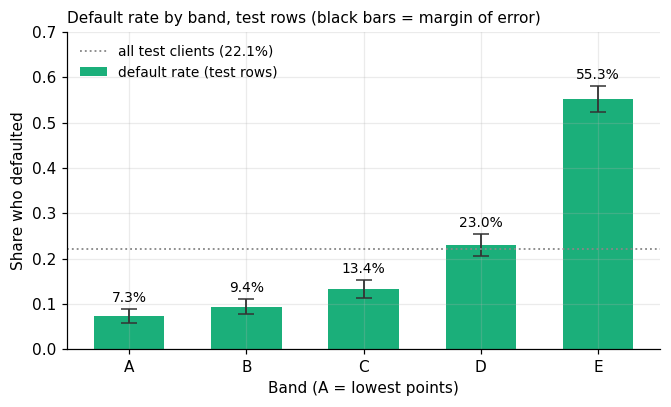

In [11]:
fig, ax = plt.subplots(figsize=(6.2, 3.8))
ax.bar(bt.index, bt["default_rate"], color=AQUA, width=0.6, label="default rate (test rows)")
ax.errorbar(bt.index, bt["default_rate"], yerr=bt["margin"], fmt="none", ecolor="#333333", capsize=5, linewidth=1.2)
ax.axhline(share, color="#888888", linewidth=1.2, linestyle=":", label=f"all test clients ({share:.1%})")
for b, r in bt["default_rate"].items():
    ax.text(b, r + bt.loc[b, "margin"] + 0.015, f"{r:.1%}", ha="center", fontsize=9)
ax.set_ylabel("Share who defaulted"); ax.set_xlabel("Band (A = lowest points)")
ax.set_ylim(0, 0.7); ax.legend(frameon=False, loc="upper left", fontsize=9)
ax.set_title("Default rate by band, test rows (black bars = margin of error)", fontsize=10, loc="left")
plt.tight_layout(); plt.show()

**Observation:** default rates rise at every step: 7.3%, 9.4%, 13.4%, 23.0%, 55.3%.
Each band's CI (`default_rate_CI`) sits entirely above the one before it, except
A to B, whose ranges overlap. The biggest jump is from D to E. For bands C, D
and E, the rate set on the validation rows falls inside the test range (for
example, band D: 0.231 on validation, 0.206 to 0.254 on test). For bands A and B
it doesn't: the test clients there defaulted less than the validation rows said
(A: 7.3% on test against 9.3%; B: 9.4% against 11.2%).

**Conclusion (check 1 of 3 passed, with two caveats):** the bands rank risk in the
right order on untouched rows. Caveat 1: bands A and B are too close to tell
apart on 6,000 test clients. This doesn't affect the cut-off (both are below
it), but anything that treats B as riskier than A, such as a higher interest rate
for B, isn't supported; they could be merged. Caveat 2: the band default
rates set on the validation rows (the `validation_rate` column) came out about 2
percentage points too high for A and B on the test rows, so for those two bands
they are cautious rather than exact.

*Pass: each client's own probability can be used. Fail, or pass only in part:
where they aren't honest, use the band default rate instead.*

**Check 2 (of 3): are the probabilities honest?** The same check as at the end of Part 3,
now on the test rows.

In [12]:
cal = honesty_table(p_test, y_test)
print(cal.round(3).to_string())
print(f"\n{(cal['within'] == 'yes').sum()} of 10 groups within their margin")
for n in [5, 20]:
    g = pd.qcut(pd.Series(p_test).rank(method="first"), n, labels=False)
    t_n = pd.DataFrame({"p": p_test, "y": y_test, "g": g}).groupby("g").agg(a=("p", "mean"), r=("y", "mean"))
    ok = ((t_n["a"] - t_n["r"]).abs() <= 2 * np.sqrt(t_n["r"] * (1 - t_n["r"]) / (len(y_test) / n))).sum()
    print(f"same check with {n} groups: {ok} of {n} within")

                    average_probability  real_share    gap  margin   real_share_CI within
group (1 = lowest)                                                                       
1                                 0.080       0.068  0.012   0.021  0.048 to 0.089    yes
2                                 0.110       0.075  0.035   0.022  0.053 to 0.097     NO
3                                 0.124       0.085  0.039   0.023  0.062 to 0.108     NO
4                                 0.134       0.108  0.026   0.025  0.083 to 0.134     NO
5                                 0.143       0.110  0.033   0.026  0.084 to 0.136     NO
6                                 0.153       0.173 -0.020   0.031  0.142 to 0.204    yes
7                                 0.161       0.192 -0.031   0.032  0.160 to 0.224    yes
8                                 0.227       0.272 -0.045   0.036  0.235 to 0.308     NO
9                                 0.409       0.440 -0.031   0.041  0.399 to 0.481    yes
10        

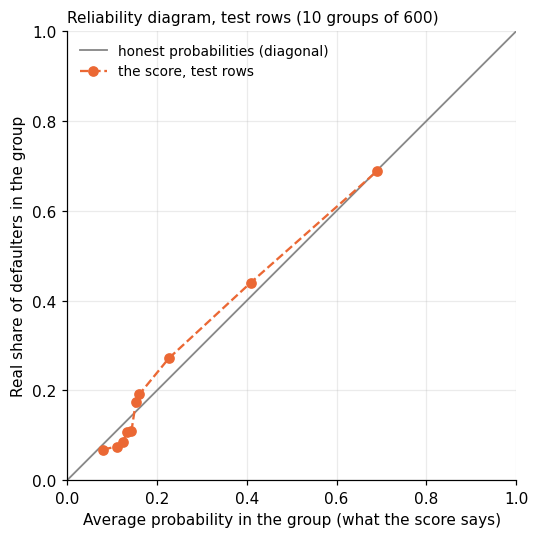

In [13]:
fig, ax = plt.subplots(figsize=(5.4, 5.0))
ax.plot([0, 1], [0, 1], color="#888888", linewidth=1.2, label="honest probabilities (diagonal)")
ax.plot(cal["average_probability"], cal["real_share"], marker="o", markersize=6, linewidth=1.5,
        linestyle="--", color=ORANGE, label="the score, test rows")
ax.set_xlabel("Average probability in the group (what the score says)")
ax.set_ylabel("Real share of defaulters in the group")
ax.set_xlim(0, 1); ax.set_ylim(0, 1); ax.set_aspect("equal")
ax.legend(frameon=False, loc="upper left", fontsize=9)
ax.set_title("Reliability diagram, test rows (10 groups of 600)", fontsize=10, loc="left")
plt.tight_layout(); plt.show()

*Reading the chart: each dot is one group of 600 test clients; the dashed line
only connects the groups in order.*

**Observation:** 5 of 10 groups are within their margin. Groups 2 to 5 get
probabilities that are too high (for example group 3: 12.4% said, 8.5% real;
group 4 misses only just, by 0.026 against a margin of 0.025), and
group 8 one that is too low (22.7% said, 27.2% real). The pattern is similar to
the validation rows (too high in the low-middle groups, too low in group 8), but
the size of the misses shifted:
- **Groups 2 to 5 miss by more on the test rows:** all four are outside their
  margin here (gaps 0.035, 0.039, 0.026, 0.033), against two of four on
  validation (groups 3 and 5).
- **Group 8 misses by less on the test rows:** a gap of 0.045 here, against 0.072
  on validation.

At both ends the score is honest (group 1: 8.0%
against 6.8%; group 10: 69.0% against 68.8%), and overall too (average
probability 0.223 against 0.221). The count depends on how many groups are used
(printed under the table: 2 of 5, 16 of 20; smaller groups have wider margins),
but the pattern of misses (where they fall and in which direction) doesn't.

**Conclusion (check 2 of 3 partly passed):** the probabilities are honest overall and
at the extremes, but in the middle, groups' average probabilities were off by up
to 4.5 percentage points on the test rows (7.2 on the validation rows). So the test rows confirm the decision made in Part 3
on the validation rows (7 of 10 groups within there, 5 of 10 here: the same
bottom line): for clients in the middle range, use the band default rate. The test rows back those rates: they held up
for bands C to E, and for A and B they erred on the cautious side (Check 1 of 3).

**The cut-off on the test rows.** Clients above 93.6 points are flagged. Precision
= the share of flagged clients who defaulted; recall = the share of all defaulters
who were flagged (Module 4).

In [14]:
flag = pts_test > CUTOFF
tp = int((flag & (y_test == 1)).sum())
print(f"flagged: {flag.sum():,} of {len(y_test):,} test clients ({flag.mean():.1%})")
print(f"precision = {tp:,} / {flag.sum():,} = {tp / flag.sum():.3f}")
print(f"recall    = {tp:,} / {int(y_test.sum()):,} = {tp / y_test.sum():.3f}")
print(f"flagged by band: " + ", ".join(f"{b} {int(flag[band_test == b].sum()):,}" for b in BANDS))

flagged: 1,835 of 6,000 test clients (30.6%)
precision = 850 / 1,835 = 0.463
recall    = 850 / 1,327 = 0.641
flagged by band: A 0, B 0, C 0, D 589, E 1,246


**Observation:** the cut-off flags 1,835 test clients (30.6%). 46.3% of them
defaulted (precision 0.463), and they include 64.1% of all defaulters (recall
0.641). It flags every client in band E, 589 of the 1,233 in band D, and none in
bands A to C.

**Conclusion:** under the assumed 5-to-1 cost ratio, a bank would decline about
3 in 10 clients and catch nearly 2 in 3 defaulters. With a different cost ratio:
- higher ratio (e.g. 10 to 1) > lower cut-off > more clients flagged > more
  defaulters caught, and more good clients declined
- lower ratio (e.g. 2 to 1) > higher cut-off > fewer clients flagged > fewer
  defaulters caught, and fewer good clients declined

### Part 5 — Check 3 (of 3): does the score work equally well across groups?
*Pass: the score can be used for all groups. Fail: it needs fixing before use.*

The score doesn't use sex, marital status or age, but other columns could carry
their information (Lesson). For each group of test clients: how many there are,
ROC-AUC (ranking within the group), the average probability against the real
share (honesty), and the margin of error on the real share. The groups: women and men
(`SEX` 2 and 1); married (`MARRIAGE` 1) and not married (everyone else: single,
"other", and the undocumented code 0); and three age groups, under 30, 30 to 39,
40 and over (a chosen split into groups of similar size, printed below). Each
group's ROC-AUC also gets a range, from 1,000 re-draws of that group's clients.

In [15]:
groups = {"women": test["SEX"] == 2, "men": test["SEX"] == 1,
          "married": test["MARRIAGE"] == 1, "not married": test["MARRIAGE"] != 1,
          "age under 30": test["AGE"] < 30, "age 30 to 39": test["AGE"].between(30, 39),
          "age 40 and over": test["AGE"] >= 40}
rows = []
rng_sub = np.random.default_rng(7)
for name, mask in groups.items():
    m = mask.to_numpy()
    r = y_test[m].mean()
    yg, pg = y_test[m], p_test[m]
    b = [roc_auc_score(yg[i], pg[i]) for i in (rng_sub.integers(0, len(yg), len(yg)) for _ in range(1000))]
    rows.append({"group": name, "clients": m.sum(), "ROC-AUC": roc_auc_score(yg, pg),
                 "ROC-AUC_CI": f"{np.percentile(b, 2.5):.3f} to {np.percentile(b, 97.5):.3f}",
                 "average probability": p_test[m].mean(), "real share": r,
                 "margin": 2 * np.sqrt(r * (1 - r) / m.sum()),
                 "flagged share": flag[m].mean(), "precision": yg[flag[m]].mean()})
sub = pd.DataFrame(rows)
sub["real_share_CI"] = [f"{r - m:.3f} to {r + m:.3f}" for r, m in zip(sub["real share"], sub["margin"])]
sub["within"] = np.where((sub["average probability"] - sub["real share"]).abs() <= sub["margin"], "yes", "NO")
sub = sub[[c for c in sub.columns if c not in ("flagged share", "precision")] + ["flagged share", "precision"]]
w = sub["group"].str.len().max()
print(sub.round(3).to_string(index=False, formatters={"group": lambda s: s.ljust(w)}, justify="left"))
print(f"\nclients aged 60 or over: {(test['AGE'] >= 60).sum()}")

group            clients  ROC-AUC ROC-AUC_CI      average probability  real share  margin real_share_CI  within  flagged share  precision
women           3642     0.773    0.754 to 0.793 0.216                0.213       0.014   0.199 to 0.227 yes    0.293          0.459     
men             2358     0.780    0.758 to 0.803 0.235                0.234       0.017   0.216 to 0.251 yes    0.326          0.469     
married         2769     0.791    0.769 to 0.810 0.227                0.238       0.016   0.221 to 0.254 yes    0.307          0.506     
not married     3231     0.764    0.742 to 0.785 0.220                0.207       0.014   0.193 to 0.221 yes    0.305          0.426     
age under 30    1907     0.770    0.742 to 0.798 0.236                0.239       0.020   0.219 to 0.258 yes    0.346          0.460     
age 30 to 39    2274     0.791    0.767 to 0.816 0.215                0.196       0.017   0.179 to 0.212  NO    0.283          0.449     
age 40 and over 1819     0.765    

**Observation:** ROC-AUC goes from 0.764 (not married) to 0.791 (married, and
age 30 to 39) across the groups, around the overall 0.7767, and every group's
range overlaps every other's. In 6 of the 7 groups the average probability is
within the margin of the real share. The one miss is age 30 to 39: 21.5% said
against 19.6% real, a gap of 0.019 against a margin of 0.017.

**Hypothesis:** the one miss is chance. The margin 2 × √(…) is the usual 95%
margin: an honest group lands outside it 5% of the time. With 7 checks, the
chance of at least one miss is 1 − 0.95⁷ ≈ 30%. That formula assumes 7 separate
checks; here each client is in 3 of the groups (sex, marital status, age), so 30%
is only approximate. And this one only just misses.

**Conclusion (check 3 of 3 passed, with a caveat):** the score can be used for all
these groups: it ranks them equally well and is equally honest for them. The
evidence:
- **Ranking:** even the largest gap between two groups of the same attribute
  (married 0.791 against not married 0.764) could be chance, because their
  `ROC-AUC_CI`s overlap (0.769 to 0.810 and 0.742 to 0.785). The smaller gaps
  (sex, age) overlap too.
- **Honesty:** 6 of 7 groups are within their margin, and the one miss is likely
  chance (Hypothesis above).

The caveat, on decisions rather than grades: unmarried clients are flagged as
often as married ones (30.5% against 30.7%), but fewer of the flagged unmarried
clients really default (precision 0.426 against 0.506), so unmarried clients are
wrongly declined more often. And the group US law specifically protects, older
applicants, can't be checked here: only 60 test clients are aged 60 or over.

### Part 6 — Independent verification
The results of Checks 1, 2 and 3 were each given to a separate reviewer (an AI agent that
had not seen this notebook), with only the claim, a file of the test clients'
probability, points, band and real outcome, and the raw data file. Each was asked
to recompute the claim from scratch and try to break it, and to give one of four
verdicts: holds / holds with a caveat / contradicted / unable to verify. Their
numbers come from their own code, so they are quoted here rather than printed above.

Both reviewers first checked the file itself: 6,000 unique clients, and every
client's real outcome matches the raw data file.

**Claim 1 (Part 4, Check 1 of 3): default rates rise from band A to band E, and each
band's CI sits above the one before it except A to B. Verdict: holds, with a
caveat.**
- Every number reproduced exactly, and every client's band matches their points.
- The reviewer also tested each step with 5,000 re-draws of the test clients:
  B→C, C→D and D→E are clearly real.
- Caveat: A→B could be chance. Band B's default rate (9.4%) is 2.1 percentage
  points above band A's (7.3%), but the CI of that difference runs from −0.1 to
  +4.3, so it includes 0. (A chi-square test of two shares, the same as A/B
  testing's two-proportion test, agrees: its p-value, the chance of a difference
  this big if the two bands were truly equal, is 0.068, above the usual 0.05
  line.)
- Resolution: treat A and B as one level of risk, or confirm on more clients.

**Claim 2 (Part 4, Check 2 of 3): the probabilities are honest overall, but not in the middle (5 of 10
groups within their margin). Verdict: holds, with a caveat.**
- Every number reproduced exactly (average probability 0.223 against 0.221;
  Brier 0.1361 against 0.1723; 5 of 10 groups).
- The middle-range miss is real, not chance. The reviewer made up outcomes 2,000
  times in which the probabilities were honest by construction (each client
  defaults exactly as often as their probability says). In that made-up world, on
  average 9.5 of 10 groups were within their margin, and never 5 or fewer. The
  real result, 5 of 10, is something honest probabilities never produced. (A standard test of
  this, the Hosmer–Lemeshow test, agrees: its p-value, the chance of misses this
  large if the probabilities were honest, is about 0.000002.)
- Caveat: the count "5 of 10" depends on the number of groups: with 5 groups,
  2 of 5 are within; with 20 groups, 16 of 20 (groups with fewer clients have
  wider margins, which hide misses). The **pattern of misses** (where they fall
  and in which direction) is the same every way: too high around 11–14%, too low
  around 16–22%.
- Resolution: report the pattern of misses, not just the count (Part 4 does).

**Claim 3 (Part 5, Check 3 of 3): the score ranks and estimates about equally well
across the 7 groups; unmarried clients are flagged as often as married ones, but
with lower precision. Verdict: holds, with a caveat.**
- Every number reproduced exactly (ROC-AUC 0.764 to 0.791; 6 of 7 groups within
  their margin; flagged 30.5% against 30.7%; precision 0.426 against 0.506).
- The reviewer also re-drew the ROC-AUC gap between each pair of groups 1,000
  times: every CI includes 0, so the ranking gaps could be chance (married against
  not married only just).
- The age 30 to 39 honesty miss is small enough to be chance once 7 groups are
  checked.
- Caveat: the precision gap for unmarried clients is real, not chance (a
  two-proportion test's p-value is 0.0006, far below the usual 0.05). So "about
  equally well" holds for ranking and honesty, not for who gets wrongly declined.
- Resolution: state the precision gap as a real finding (Part 5's caveat does).

**Conclusion:** the results of Checks 1, 2 and 3 hold, with the caveats above now stated in
Part 4 and in the takeaways.

## Exercise: the score memo
Write a short memo to a credit manager: what the score is, how well it works,
where it shouldn't be trusted. A worked answer follows.

**Worked answer.**

> **To:** Credit manager  **Re:** the new risk score
>
> **What it is.** A points score from 4 facts about a client: credit limit,
> months late in September, months late over August to April, and the amount paid
> in September. More points = more risk; every 20 points doubles the odds of
> default. Clients fall into bands A (lowest risk) to E. It uses no personal
> attributes (sex, marital status, age): laws such as the US Equal Credit
> Opportunity Act forbid or restrict them, and leaving all three out is the
> simplest safe design.
>
> **How well it works (on 6,000 clients it had never seen).** It ranks clients
> well (ROC-AUC 0.7767, range 0.7622 to 0.7920). Default rates rise from band to
> band: A 7.3%, B 9.4%, C 13.4%, D 23.0%, E 55.3%. Flagging clients above 93.6
> points (which assumes a missed default costs 5 times a wrongly declined client)
> flags 30.6% of clients and catches 64.1% of defaulters; 46.3% of the flagged
> clients default. It ranks and estimates about equally well for women and men,
> married and not, and across age groups (one borderline miss in honesty, ages 30
> to 39). But unmarried clients who are declined turn out to be good clients more
> often than married ones (precision 0.426 against 0.506), so review that before
> use.
>
> **Where not to trust it.**
> - **Exact probabilities in the middle of the range.** Between about 11% and 22%,
>   groups of clients' probabilities were off by up to 4.5 percentage points on
>   the test (7.2 on earlier rows). For those clients, use the band's default rate instead.
> - **A versus B.** The difference between the two lowest bands could be chance;
>   treat them as one level of risk.
> - **The cut-off** rests on an assumed cost ratio (5 to 1). Give us your real
>   costs and it moves. Even at 5 to 1, it may be set a little high.
> - **What "default" means** is not defined in the source data; the score
>   predicts the bank's label, whatever rule produced it.
> - **Time and place:** the data is one period in Taiwan in 2005 (Part 0). The score must
>   be re-checked before use elsewhere, and regularly after.
> - **Not a cause:** the points say who defaulted more often, not why.

## Key takeaways
- **Conclusion:** a points score needs a model where each column adds its own
  amount: logistic regression, not the forest. On the same 15 columns, the
  forest ranked better by 0.0255 of ROC-AUC on the validation rows.
- **Conclusion:** leaving out sex, marital status and age, as lending law
  requires, cost 0.0046 of ROC-AUC here, and the finished score ranked and
  estimated about equally well across those groups (one borderline miss among the 7 groups checked: ages 30 to 39),
  though unmarried clients are wrongly declined more often than married ones.
- **Conclusion:** on untouched test rows, the score ranks clients well
  (ROC-AUC 0.7767) and the bands rise from A to E (7.3% to 55.3%); A and B are
  too close to tell apart. Independently verified, with that caveat.
- **Conclusion:** the probabilities are honest overall, but in the middle of the
  range groups' averages were off by up to 4.5 percentage points on the test
  rows: a real pattern (independently verified), already visible on the
  validation rows. With an honest model, a client's own probability is the best
  number; with this one, use the band default rate for clients in the middle
  range.
- **Conclusion:** a cut-off follows from the cost of each kind of mistake:
  flag when p > cost of a false alarm ÷ (cost of a false alarm + cost of a missed
  default). The costs are an input from the business, not something the data can
  supply.
- **Conclusion:** the score predicts what the bank labelled default in this data;
  it says nothing about why clients default.